# GRAFO DE RELACIONES ENTRE PARTICIPANTES DEL 23F

Instalar librerías requeridas para el análisis

In [ ]:
!jupyter nbconvert --to markdown Relaciones_23F_v1_3.ipynb

In [ ]:
# Install Libraries
!pip install spacy
!pip install altair
!pip install sentence-transformers
!pip install gensim
!python -m spacy download es_core_news_lg
!pip install networkx pyvis

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
from sentence_transformers import SentenceTransformer
import numpy as np
import requests
from lxml import html
from tqdm import tqdm
import os
import hashlib
import spacy
import gensim
import nltk
import altair as alt
from collections import defaultdict

## Carga de documentos scrapeados

In [ ]:
from google.colab import files
files.upload()

In [ ]:
df = pd.read_csv('23f_scrappedDF_v02.csv')

In [ ]:
df.head(1)

## Análisis Estadístico - Dataframe 23F

In [ ]:
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print("\nTipos de dato:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nEjemplo de transcript:")
print(df['transcript'][0][:500])

In [ ]:
print(df['transcript'][0])

In [ ]:
df.head(1)

## Limpieza Basica usando spaCy

In [ ]:
# Carga el modelo español grande
nlp = spacy.load("es_core_news_lg")

# Verifica que cargó correctamente
print(nlp.pipe_names)  # ['tok2vec', 'morphologizer', 'parser', 'ner', ...]

Limpieza básica previa antes de pasar el texto a spaCy (Claude lo sugiere así para hacer primero limpieza y luego procesamiento linguistico con spaCy)

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)  # control chars
    text = re.sub(r'\n+', ' ', text) # Elimina saltos de línea
    text = re.sub(r'\s+', ' ', text) # Colapsa espacios múltiples
    text = re.sub(r'[^\w\s.,;:áéíóúüñÁÉÍÓÚÜÑ]', '', text) # Conserva puntuación básica y tildes
    return text.strip()

In [ ]:
df['transcript_clean'] = df['transcript'].apply(clean_text)

In [ ]:
df['transcript_clean'][0]

Procesamiento linguistico por batches con spaCy

In [ ]:
# batch_size=32 es un buen punto de partida; auméntalo si tienes RAM suficiente
docs = list(nlp.pipe(df['transcript_clean'], batch_size=32))

# Guarda los objetos Doc en el DataFrame para reutilizarlos
df['spacy_doc'] = docs

In [ ]:
df['spacy_doc'][0]

## Extracción de Features Linguisticos

In [ ]:
def extract_features(doc):
    return {
        "tokens": [token.text for token in doc if not token.is_stop and not token.is_punct],
        "lemmas": [token.lemma_ for token in doc if not token.is_stop and not token.is_punct],
        "entities": [(ent.text, ent.label_) for ent in doc.ents],
        "sentences": [sent.text for sent in doc.sents]
    }

df['nlp_features'] = df['spacy_doc'].apply(extract_features)

In [ ]:
df['nlp_features'][0]

### Named Entities Recognition (NER)

In [ ]:
# Tipos de entidad relevantes para el análisis del 23-F
ENTITY_TYPES = {
    "PER": "Persona",
    "LOC": "Lugar",
    "ORG": "Organización"
}

# Cargar modelo (reutilizar si ya está en memoria desde Fase 0)
nlp = spacy.load("es_core_news_lg")

print(f"Modelo cargado: {nlp.meta['name']} v{nlp.meta['version']}")
print(f"Componentes activos: {nlp.pipe_names}")
print(f"Tipos de entidad a extraer: {list(ENTITY_TYPES.keys())}")

Identificación de Entidades Nombradas en el texto normalizado

In [ ]:
# Prefijos de rango/tratamiento ordenados de mayor a menor longitud
RANK_PREFIXES = sorted([
    "teniente coronel", "teniente general", "capitán general",
    "teniente", "general", "coronel", "capitán", "comandante",
    "almirante", "sargento", "cabo 1º", "cabo 12", "cabo",
    "gral.", "gral", "tcol.", "tcol", "tte.", "tte", "cte.", "cte",
    "cap.", "cap", "sgto.", "sgto",
    "sr. don", "sr. d.", "sr.", "don", "doña", "d.",
    "señor", "señora", "el", "la",
], key=len, reverse=True)

def strip_rank_prefix(name: str) -> str:
    """
    Elimina prefijos de rango/tratamiento para obtener el nombre canónico.
    'coronel tejero'         → 'tejero'
    'teniente coronel tejero'→ 'tejero'
    'sr. don antonio tejero' → 'antonio tejero'
    'carmen tejero'          → 'carmen tejero'  (sin cambio, no hay prefijo)
    """
    changed = True
    while changed:
        changed = False
        name_lower = name.lower()
        for prefix in RANK_PREFIXES:
            if name_lower.startswith(prefix + " "):
                name = name[len(prefix):].strip()
                name_lower = name.lower()
                changed = True
                break
        # Evitar que el resultado caiga en el blocklist
        if name.lower() in ENTITY_BLOCKLIST:
            return ""   # descartará la entidad al hacer el filtro
    return name

def merge_suffix_variants(entity_set: set) -> set:
    """
    Fusiona variantes de nombre dentro del mismo documento.
    Si A es sufijo de B (misma clase), A es redundante → se elimina.

    {'tejero', 'antonio tejero', 'carmen tejero'}
      → 'tejero' es sufijo de 'antonio tejero' Y de 'carmen tejero'
      → resultado: {'antonio tejero', 'carmen tejero'}

    {'armada', 'alfonso armada'}
      → 'armada' es sufijo de 'alfonso armada'
      → resultado: {'alfonso armada'}
    """
    to_remove = set()
    entity_list = list(entity_set)
    for e_short in entity_list:
        for e_long in entity_list:
            if e_short != e_long and e_long.endswith(" " + e_short):
                to_remove.add(e_short)
                break
    return entity_set - to_remove

In [ ]:
texts = df["transcript_clean"].tolist()
total_docs = len(texts)
BATCH_SIZE = 8

print(f"Procesando {total_docs} documentos con NER (batch_size={BATCH_SIZE})...")

# nlp.pipe() devuelve un generador, tqdm lo envuelve sin romper el batch interno
docs = []

with tqdm(
    nlp.pipe(texts, batch_size=BATCH_SIZE),
    total=total_docs,
    desc="NER Fase 1",
    unit="doc",
    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} docs [{elapsed}<{remaining}, {rate_fmt}]"
) as pbar:
    for doc in pbar:
        docs.append(doc)

        # Actualiza el postfix cada BATCH_SIZE documentos para no saturar la UI
        if len(docs) % BATCH_SIZE == 0:
            ents_so_far = sum(
                1 for d in docs for e in d.ents if e.label_ in ENTITY_TYPES
            )
            pbar.set_postfix({
                "entidades": ents_so_far,
                "batch": f"{len(docs) // BATCH_SIZE}/{-(-total_docs // BATCH_SIZE)}"  # ceil division
            })

print(f"\nCompletado. {len(docs)} documentos procesados.")
print(f"Total entidades encontradas: {sum(1 for d in docs for e in d.ents if e.label_ in ENTITY_TYPES)}")

Generacion del DataFrame de Entidades Nombradas

Determinar si es una entidad real o si debe filtrarse, con base en tipología de spaCy

In [ ]:
# --- Constantes nuevas (añadir ANTES de is_valid_entity) ---

# Palabras que nunca son entidades válidas solas
ENTITY_BLOCKLIST = {
    "general", "generales", "teniente", "tenientes", "coronel", "coroneles",
    "capitán", "capitanes", "comandante", "comandantes", "almirante",
    "sargento", "sargentos", "cabo", "subteniente",
    "incidencias", "actuaciones", "situaciones", "desarrollo",
    "militares", "policías", "guardias", "funcionarios",
    "desarrollo de", "situaciones de", "actuaciones de",
}

# Patrón de artefacto de diálogo: letra/abrev. + espacios = etiqueta de interlocutor
# Captura: "a  buenas", "b  sí", "g.c. hijo", "t. armada"
DIALOGUE_ARTIFACT_RE = re.compile(r'^[a-z]\.?\s{1,3}\S')

# Detecta strings con dígitos mezclados con letras (códigos de documento)
CODE_PATTERN = re.compile(r'\d{3,}')  # 3+ dígitos consecutivos = código

def is_valid_entity(ent) -> bool:
    tokens = [token for token in ent]
    text   = ent.text.strip()
    text_l = text.lower()

    # NUEVA Regla 1: rechazar artefactos de diálogo (etiquetas de interlocutor)
    if DIALOGUE_ARTIFACT_RE.match(text_l):
        return False

    # NUEVA Regla 2: rechazar palabras en el blocklist (rangos solos, genéricos)
    if text_l in ENTITY_BLOCKLIST or text_l.rstrip('.') in ENTITY_BLOCKLIST:
        return False

    # Regla 3: al menos un token debe ser PROPN o NOUN
    if not any(t.pos_ in ("PROPN", "NOUN") for t in tokens):
        return False

    # Regla 4: no puede ser solo ADJ, ADV, VERB o DET
    if all(t.pos_ in ("ADJ", "ADV", "VERB", "DET") for t in tokens):
        return False

    # Regla 5: longitud mínima
    if len(text) <= 2:
        return False

    # Regla 6: rechazar códigos con dígitos
    if CODE_PATTERN.search(text):
        return False

    # Regla 7: rechazar frases largas
    if len(tokens) > 5:
        return False

    # Regla 8: rechazar si contiene VERB
    if any(t.pos_ == "VERB" for t in tokens):
        return False

    # Regla 9: rechazar si contiene artículos o preposiciones internas
    internal_tokens = tokens[1:-1]
    if any(t.pos_ in ("DET", "ADP") for t in internal_tokens):
        return False

    # NUEVA Regla 10: PER debe tener al menos 1 PROPN
    # Bloquea sustantivos comunes que spaCy etiqueta PER (e.g. "incidencias")
    if ent.label_ == "PER" and not any(t.pos_ == "PROPN" for t in tokens):
        return False

    return True

In [ ]:
# --- Estructura 1: entidades agregadas por documento ---
entity_records = []

for idx, (doc_idx, row) in enumerate(df.iterrows()):
    doc = docs[idx]
    entities = defaultdict(set)

    for ent in doc.ents:
        if ent.label_ in ENTITY_TYPES and is_valid_entity(ent):  # <-- filtro aplicado
            normalized = strip_rank_prefix(ent.text.strip().lower())
            if normalized:                          # strip_rank_prefix devuelve "" si cae en blocklist
              entities[ent.label_].add(normalized)

    # Fusionar variantes de sufijo dentro del documento
    for label in list(entities.keys()):
      entities[label] = merge_suffix_variants(entities[label])

    entity_records.append({
        "doc_id":          row.get("doc_id", doc_idx),
        "persons":         sorted(list(entities.get("PER", []))),
        "locations":       sorted(list(entities.get("LOC", []))),
        "organizations":   sorted(list(entities.get("ORG", []))),
        "n_persons":       len(entities.get("PER", [])),
        "n_locations":     len(entities.get("LOC", [])),
        "n_organizations": len(entities.get("ORG", []))
    })

df_entities = pd.DataFrame(entity_records)

df_entities["total_entities"] = (
    df_entities["n_persons"] +
    df_entities["n_locations"] +
    df_entities["n_organizations"]
)

# --- Estructura 2: registro plano de menciones ---
mention_records = []

for idx, (doc_idx, row) in enumerate(df.iterrows()):
    doc = docs[idx]
    doc_id = row.get("doc_id", doc_idx)

    for ent in doc.ents:
        if ent.label_ in ENTITY_TYPES and is_valid_entity(ent):  # <-- filtro aplicado
            normalized = strip_rank_prefix(ent.text.strip().lower())
            if not normalized:
              continue                            # saltar entidades que quedaron vacías
            ctx_start = max(0, ent.start - 5)
            ctx_end   = min(len(doc), ent.end + 5)

            mention_records.append({
                "doc_id":      doc_id,
                "entity_raw":  ent.text.strip(),
                "entity_norm": normalized,
                "label":       ent.label_,
                "label_desc":  ENTITY_TYPES[ent.label_],
                "context":     doc[ctx_start:ctx_end].text
            })

df_mentions = pd.DataFrame(mention_records)

print(f"df_entities shape: {df_entities.shape}")
print(f"df_mentions shape: {df_mentions.shape}")
print(f"\nTotal menciones por tipo:\n{df_mentions['label'].value_counts()}")

In [ ]:
# Entidades a inyectar manualmente por documento
MANUAL_INJECTIONS = [
    {"doc_id": 61, "entity_raw": "Consejo de Guerra", "entity_norm": "consejo de guerra", "label": "ORG"},
    # Añade más filas aquí si aparecen casos similares en otros docs
]

for inj in MANUAL_INJECTIONS:
    inj["label_desc"]     = ENTITY_TYPES.get(inj["label"], inj["label"])
    inj["context"]        = ""
    inj["label_resolved"] = inj["label"]

df_injections = pd.DataFrame(MANUAL_INJECTIONS)
df_mentions   = pd.concat([df_mentions, df_injections], ignore_index=True)

print(f"Inyecciones aplicadas: {len(MANUAL_INJECTIONS)}")
print(df_mentions[df_mentions["doc_id"] == 61])

## Revisión de calidad de las entidades encontradas

In [ ]:
# Entidades más frecuentes por tipo
print("=" * 50)
print("TOP 10 ENTIDADES POR TIPO")
print("=" * 50)

for label, desc in ENTITY_TYPES.items():
    top = (
        df_mentions[df_mentions["label"] == label]["entity_norm"]
        .value_counts()
        .head(10)
    )
    print(f"\n{desc} ({label}):")
    print(top.to_string())

# Documentos con mayor densidad de entidades
print("\n" + "=" * 50)
print("DOCUMENTOS CON MÁS ENTIDADES")
print("=" * 50)

print(df_entities[["doc_id", "n_persons", "n_locations", "n_organizations", "total_entities"]]
      .sort_values("total_entities", ascending=False)
      .head(10)
      .to_string(index=False))

# Muestra de menciones con contexto (útil para revisar falsos positivos)
print("\n" + "=" * 50)
print("MUESTRA DE MENCIONES CON CONTEXTO")
print("=" * 50)
print(df_mentions.sample(min(10, len(df_mentions)))[
    ["doc_id", "label_desc", "entity_norm", "context"]
].to_string(index=False))

Corrección de Conflictos Identificados entre Entidades

In [ ]:
# Contar menciones por (entity_norm, label)
vote_counts = (
    df_mentions
    .groupby(["entity_norm", "label"])
    .size()
    .reset_index(name="count")
)

# Para cada entidad, quedarse con el label de mayor frecuencia
winning_label = (
    vote_counts
    .sort_values("count", ascending=False)
    .drop_duplicates(subset="entity_norm", keep="first")
    .set_index("entity_norm")["label"]
)

# Identificar entidades con conflicto (aparecen en más de un tipo)
conflict_entities = (
    vote_counts
    .groupby("entity_norm")["label"]
    .nunique()
    .loc[lambda x: x > 1]
    .index.tolist()
)

print(f"Entidades con conflicto de tipo: {len(conflict_entities)}")
print(f"\nDetalle de conflictos:")
print(
    vote_counts[vote_counts["entity_norm"].isin(conflict_entities)]
    .sort_values(["entity_norm", "count"], ascending=[True, False])
    .to_string(index=False)
)

Agregar Prioridad en Reconocimiento de Entidades

In [ ]:
# Prioridad: 1 = máxima prioridad
LABEL_PRIORITY = {"PER": 1, "ORG": 2, "LOC": 3}

def resolve_label(entity_norm, vote_counts_df, priority_map):
    """
    Resuelve conflictos combinando frecuencia y prioridad de dominio.
    Si el label mayoritario y el de mayor prioridad difieren,
    el de mayor prioridad gana solo si su frecuencia >= 30% del total.
    """
    rows = vote_counts_df[vote_counts_df["entity_norm"] == entity_norm].copy()

    if len(rows) == 1:
        return rows.iloc[0]["label"]

    total = rows["count"].sum()
    rows["pct"] = rows["count"] / total
    rows["priority"] = rows["label"].map(priority_map)

    # Label de mayor prioridad con al menos 30% de las menciones
    high_priority = rows[rows["pct"] >= 0.30].sort_values("priority")

    if not high_priority.empty:
        return high_priority.iloc[0]["label"]

    # Si ninguno alcanza el 30%, gana el mayoritario
    return rows.sort_values("count", ascending=False).iloc[0]["label"]


# Construir mapa definitivo entity_norm -> label correcto
resolved_labels = {
    entity: resolve_label(entity, vote_counts, LABEL_PRIORITY)
    for entity in conflict_entities
}

# Completar con entidades sin conflicto
for entity, label in winning_label.items():
    if entity not in resolved_labels:
        resolved_labels[entity] = label

print("Resolución de conflictos:")
for entity in conflict_entities:
    rows = vote_counts[vote_counts["entity_norm"] == entity]
    final = resolved_labels[entity]
    print(f"  '{entity}': {dict(zip(rows['label'], rows['count']))} -> {final}")

Agregar Whitelist de Entidades Conocidas con base en el Contexto

In [ ]:
# Entidades clave del 23-F con su tipo correcto
KNOWN_ENTITIES_23F = {
    # --- Personas (existentes) ---
    "rey":               "PER",
    "tejero":            "PER",
    "antonio tejero":    "PER",         # añadir forma media
    "tejero molina":     "PER",         # añadir forma media
    "milans del bosch":  "PER",
    "milans":            "PER",         # añadir
    "armada":            "PER",
    "alfonso armada":    "PER",         # añadir
    "general armada":    "PER",         # FIX: era ORG → PER
    "gral armada":       "PER",         # añadir variante
    "suárez":            "PER",
    "adolfo suárez":     "PER",         # añadir
    "gutiérrez mellado": "PER",
    "calvo sotelo":      "PER",
    "leopoldo calvo sotelo": "PER",     # añadir
    "aramburu":          "PER",
    "gabeiras":          "PER",         # añadir (jefe del Ejército)
    "fernández campos":  "PER",         # añadir (Secretario de la Casa Real)
    "sabino fernández campos": "PER",   # añadir
    "cortina":           "PER",         # añadir (comandante Cortina)
    "san martín":        "PER",         # añadir
    "torres rojas":      "PER",         # añadir
    "pardo zancada":     "PER",         # añadir
    # --- Lugares (existentes + nuevos) ---
    "valencia":          "LOC",
    "madrid":            "LOC",
    "españa":            "LOC",
    "zarzuela":          "LOC",         # añadir (Palacio de la Zarzuela)
    "moncloa":           "LOC",         # añadir
    # --- Organizaciones (existentes + nuevos) ---
    "guardia civil":     "ORG",
    "psoe":              "ORG",
    "ucd":               "ORG",
    "gobierno":          "ORG",
    "congreso":          "ORG",
    "congreso de los diputados": "ORG",
    "fuerzas armadas":   "ORG",         # FIX: era incorrecto
    "división acorazada": "ORG",        # añadir
    "cesid":             "ORG",         # añadir (servicio de inteligencia)
    "ministerio de defensa":    "ORG",
    "ministerio del interior":  "ORG",
    "parlamento":        "ORG",
    "tribunal":          "ORG",
    "consejo de guerra": "ORG",
    "consejo supremo":   "ORG",         # añadir
    "bripac":            "ORG",         # añadir (brigada paracaidista)
}

# La whitelist sobreescribe cualquier resultado previo
resolved_labels.update(KNOWN_ENTITIES_23F)

print(f"Whitelist aplicada: {len(KNOWN_ENTITIES_23F)} entidades fijadas manualmente.")

Corrección de Entidades con Base en Estrategias y Whitelist

In [ ]:
# Corregir el label en df_mentions
df_mentions["label_resolved"] = df_mentions["entity_norm"].map(resolved_labels)

# Verificar que no haya NaN (entidades sin resolución)
missing = df_mentions[df_mentions["label_resolved"].isna()]["entity_norm"].unique()
if len(missing) > 0:
    print(f"Advertencia: {len(missing)} entidades sin label resuelto. Rellenando con label original.")
    df_mentions["label_resolved"] = df_mentions["label_resolved"].fillna(df_mentions["label"])

# Reconstruir df_entities con los labels corregidos
entity_records_clean = []

for doc_id, group in df_mentions.groupby("doc_id"):
    entities = defaultdict(set)
    for _, row in group.iterrows():
        entities[row["label_resolved"]].add(row["entity_norm"])

    entity_records_clean.append({
        "doc_id":          doc_id,
        "persons":         sorted(list(entities.get("PER", []))),
        "locations":       sorted(list(entities.get("LOC", []))),
        "organizations":   sorted(list(entities.get("ORG", []))),
        "n_persons":       len(entities.get("PER", [])),
        "n_locations":     len(entities.get("LOC", [])),
        "n_organizations": len(entities.get("ORG", [])),
    })

df_entities_clean = pd.DataFrame(entity_records_clean)
df_entities_clean["total_entities"] = (
    df_entities_clean["n_persons"] +
    df_entities_clean["n_locations"] +
    df_entities_clean["n_organizations"]
)

print(f"df_entities_clean shape: {df_entities_clean.shape}")
print(f"\nTotal menciones por tipo (después de corrección):")
print(df_mentions["label_resolved"].value_counts())

In [ ]:
df_entities_clean.head(5)

Merge de Entidades Corregidas con el DF Original

In [ ]:
# Añadir doc_id al DataFrame original si no existe
if "doc_id" not in df.columns:
    df["doc_id"] = df.index

df = df.merge(
    df_entities_clean[[
        "doc_id", "persons", "locations", "organizations",
        "n_persons", "n_locations", "n_organizations", "total_entities"
    ]],
    on="doc_id",
    how="left"
)

In [ ]:
print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
print(f"Nulos en persons: {df['persons'].isna().sum()}")  # debe ser 0

In [ ]:
# Ver qué IDs no matchearon
ids_df      = set(df["doc_id"])
ids_clean   = set(df_entities_clean["doc_id"])
print("En df pero no en df_entities_clean:", ids_df - ids_clean)

In [ ]:
df.loc[df['doc_id'] == 61]

In [ ]:
df_entities_clean.loc[[60]]

In [ ]:
df['transcript_clean'][61]

In [ ]:
# Paso 1: ¿El doc tiene menciones en df_mentions?
print(df_mentions[df_mentions["doc_id"] == 61])

# Paso 2: ¿Qué extrajo spaCy antes del filtro?
doc_61 = docs[61]
print("Entidades crudas de spaCy:")
for ent in doc_61.ents:
    print(f"  '{ent.text}' | label={ent.label_} | valid={is_valid_entity(ent)}")

# Paso 3: ¿Qué dice el transcript?
print("\nTranscript limpio:")
print(df["transcript_clean"].iloc[61][:500])

Exportar Outputs

In [ ]:
# Guardar para Fase 2
df_entities_clean.to_csv("fase1_entities_by_doc.csv", index=False)
df_mentions.to_csv("fase1_mentions.csv", index=False)
df_entities_clean.to_markdown("entities_clean.md", tablefmt="grid")
df_mentions.to_markdown("mentions.md", tablefmt="grid")

print("Outputs de Fase 1 guardados:")
print("  - fase1_entities_by_doc.csv  (entidades por documento)")
print("  - fase1_mentions.csv         (registro plano de menciones)")
print(f"\nDataFrame principal df ahora tiene {df.shape[1]} columnas.")
print(f"Columnas nuevas: persons, locations, organizations, n_*, total_entities")

## Grafo de Coocurrencia entre Entidades

### Construcción de Pares de Coocurrencia

In [ ]:
from itertools import combinations
from collections import defaultdict
import networkx as nx

# Mínimo de documentos donde deben co-ocurrir dos entidades para crear arco
MIN_COOC = 10

edge_weights = defaultdict(int)

for _, row in df_entities_clean.iterrows():
    # Recopilar todas las entidades del documento con su tipo
    all_entities = (
        [(e, "PER") for e in row["persons"]]
        + [(e, "ORG") for e in row["organizations"]]
        + [(e, "LOC") for e in row["locations"]]
    )

    # Generar todos los pares únicos dentro del mismo documento
    for (e1, t1), (e2, t2) in combinations(all_entities, 2):
        edge_key = tuple(sorted([e1, e2]))  # arco no dirigido
        edge_weights[edge_key] += 1

print(f"Pares únicos encontrados: {len(edge_weights)}")
print(f"Pares con co-ocurrencia >= {MIN_COOC}: {sum(1 for v in edge_weights.values() if v >= MIN_COOC)}")

### Generar Grafo de Entidades

In [ ]:
# Mapa entidad -> tipo (desde df_mentions ya resuelto)
entity_type_map = (
    df_mentions
    .drop_duplicates(subset="entity_norm")
    .set_index("entity_norm")["label_resolved"]
    .to_dict()
)

# Colores por tipo para visualización
TYPE_COLORS = {"PER": "#4C9BE8", "ORG": "#E8874C", "LOC": "#6ABF69", "UNK": "#AAAAAA"}

G = nx.Graph()

for (e1, e2), weight in edge_weights.items():
    if weight >= MIN_COOC:
        G.add_edge(e1, e2, weight=weight)

# Añadir atributos a los nodos
for node in G.nodes():
    etype = entity_type_map.get(node, "UNK")
    G.nodes[node]["type"]  = etype
    G.nodes[node]["color"] = TYPE_COLORS[etype]

print(f"Nodos: {G.number_of_nodes()}")
print(f"Arcos: {G.number_of_edges()}")
print(f"Componentes conectados: {nx.number_connected_components(G)}")

### Evaluar Metricas de Centralidad

In [ ]:
# Centralidades principales
degree_cent     = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G, weight="weight")
weighted_degree  = dict(G.degree(weight="weight"))

df_centrality = pd.DataFrame({
    "entity":      list(G.nodes()),
    "type":        [G.nodes[n]["type"] for n in G.nodes()],
    "degree":      [G.degree(n) for n in G.nodes()],
    "weighted_deg":[weighted_degree[n] for n in G.nodes()],
    "degree_cent": [degree_cent[n] for n in G.nodes()],
    "betweenness": [betweenness_cent[n] for n in G.nodes()],
}).sort_values("betweenness", ascending=False)

print("Top 15 entidades por betweenness centrality:")
print(df_centrality.head(15).to_string(index=False))

### Visualización del Grafo de Entidades (Matplotlib)

In [ ]:
# Filtrar solo nodos con degree suficiente para no saturar el grafo
MIN_DEGREE = 10
subgraph_nodes = [n for n, d in G.degree() if d >= MIN_DEGREE]
G_sub = G.subgraph(subgraph_nodes)

plt.figure(figsize=(18, 14))

pos = nx.spring_layout(G_sub, weight="weight", seed=42, k=0.6)

node_colors = [G_sub.nodes[n]["color"] for n in G_sub.nodes()]
node_sizes  = [300 + G_sub.degree(n) * 40 for n in G_sub.nodes()]
edge_widths = [G_sub[u][v]["weight"] * 0.3 for u, v in G_sub.edges()]

nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(G_sub, pos, width=edge_widths, alpha=0.4, edge_color="#888888")
nx.draw_networkx_labels(G_sub, pos, font_size=7, font_color="black")

# Leyenda
from matplotlib.patches import Patch
legend = [Patch(color=v, label=k) for k, v in TYPE_COLORS.items() if k != "UNK"]
plt.legend(handles=legend, loc="upper left", fontsize=10)

plt.title("Grafo de Co-ocurrencia de Entidades — 23F", fontsize=14, pad=20)
plt.axis("off")
plt.tight_layout()
plt.savefig("fase2_grafo_entidades.png", dpi=150, bbox_inches="tight")
plt.show()

### Grafo de Entidades Interactivo (PyVis)

In [ ]:
from pyvis.network import Network

net = Network(height="750px", width="100%", bgcolor="#1a1a2e", font_color="white")
net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=150)

for node in G_sub.nodes(data=True):
    name, attrs = node
    size = 10 + G_sub.degree(name) * 2
    net.add_node(name, label=name, color=attrs["color"], size=size,
                 title=f"{attrs['type']}: {name}\nDegree: {G_sub.degree(name)}")

for u, v, data in G_sub.edges(data=True):
    net.add_edge(u, v, width=data["weight"] * 0.3,
                 title=f"Co-ocurrencias: {data['weight']}")

net.save_graph("fase2_grafo_interactivo.html")
print("Grafo interactivo guardado: fase2_grafo_interactivo.html")

## Enriquecer el Grafo con Inferencia de Jerarquía y Afiliación

In [44]:
# ==========================================
# PASO 3.1: CREACIÓN DEL GRAFO A (DIRIGIDO)
# ==========================================

G_A = nx.DiGraph()

# Heredar los nodos del grafo base con sus atributos originales
for node, attrs in G.nodes(data=True):
    G_A.add_node(node, **attrs)

print(f"Grafo A inicializado con {G_A.number_of_nodes()} nodos de la Fase 2.")

Grafo A inicializado con 70 nodos de la Fase 2.


In [46]:
# =====================================================================
# PASO 3.2: FUNCIÓN MAESTRA DE INFERENCIA DE RELACIONES SINTÁCTICAS
# =====================================================================

def infer_relations_step(df_input, label_map):
    inferred_edges = []

    # Palabras clave y lemas de control
    mando_verbs = {'ordenar', 'mandar', 'disponer', 'dirigir', 'instruir', 'comandar'}
    affiliation_triggers = {'del', 'de la', 'de los', 'perteneciente', 'miembro', 'integrante', 'destino'}

    for idx, row in df_input.iterrows():
        doc = row['spacy_doc']
        if not hasattr(doc, 'sents'):
            continue

        for sent in doc.sents:
            # 1. Extraer y normalizar entidades válidas en esta oración particular
            sent_ents = []
            for ent in sent.ents:
                if is_valid_entity(ent):
                    norm = strip_rank_prefix(ent.text.strip().lower())
                    etype = label_map.get(norm)
                    if etype:
                        sent_ents.append({'norm': norm, 'type': etype, 'ent_obj': ent})

            if len(sent_ents) < 2:
                continue

            # Separar por tipos para optimizar combinaciones
            persons = [e for e in sent_ents if e['type'] == 'PER']
            organizations = [e for e in sent_ents if e['type'] == 'ORG']

            # --- REGLA A: AFILIACIÓN (PER -> ORG) ---
            for p in list(persons):
                for o in list(organizations):
                    is_affiliated = False
                    p_ent = p['ent_obj']
                    o_ent = o['ent_obj']

                    # Chequeo Sintáctico: ¿La organización modifica al nombre/rango?
                    for token in o_ent:
                        # Si la raíz de la ORG depende de una preposición conectada a la PERSONA
                        if token.head.dep_ == 'prep' and token.head.head in p_ent:
                            is_affiliated = True
                            break

                    # Chequeo Léxico (Ventana de proximidad corta + conector de pertenencia)
                    if not is_affiliated:
                        p_start, p_end = p_ent.start, p_ent.end
                        o_start, o_end = o_ent.start, o_ent.end
                        if abs(o_start - p_end) <= 5 or abs(p_start - o_end) <= 5:
                            min_idx = min(p_end, o_end)
                            max_idx = max(p_start, o_start)
                            middle_text = doc[min_idx:max_idx].text.lower()
                            if any(trigger in middle_text for trigger in affiliation_triggers):
                                is_affiliated = True

                    if is_affiliated:
                        inferred_edges.append({
                            'source': p['norm'], 'target': o['norm'],
                            'type': 'affiliation', 'context': sent.text.strip()
                        })

            # --- REGLA B: JERARQUÍA (PER -> PER) ---
            for i, p1 in enumerate(persons):
                for j, p2 in enumerate(persons):
                    if i == j: continue
                    p1_ent, p2_ent = p1['ent_obj'], p2['ent_obj']
                    is_hierarchy = False
                    commander, subordinate = None, None

                    # Chequeo Sintáctico mediante Verbos de Mando
                    for token in sent:
                        if token.lemma_ in mando_verbs:
                            # Obtener dependientes directos del verbo
                            children = list(token.children)
                            subjs = [t for t in children if t.dep_ in ('nsubj', 'nsubjpass')]
                            objs = [t for t in children if t.dep_ in ('obj', 'iobj')]

                            # Validar si p1 es sujeto (manda) y p2 es objeto (recibe orden)
                            p1_is_subj = any(t in p1_ent for t in subjs)
                            p2_is_obj = any(t in p2_ent or (t.head in p2_ent) for t in objs)

                            if p1_is_subj and p2_is_obj:
                                is_hierarchy = True
                                commander, subordinate = p1['norm'], p2['norm']
                                break

                    # Chequeo Léxico: Fórmulas de respeto militar ("a las órdenes de", "mi general")
                    if not is_hierarchy:
                        p1_start, p1_end = p1_ent.start, p1_ent.end
                        p2_start, p2_end = p2_ent.start, p2_ent.end

                        # Patrón "Subordinado a las órdenes de Comandante"
                        if abs(p1_start - p2_end) <= 6:
                            middle_text = doc[p2_end:p1_start].text.lower()
                            if 'órdenes de' in middle_text or 'mando de' in middle_text:
                                is_hierarchy = True
                                commander, subordinate = p1['norm'], p2['norm']

                        elif abs(p2_start - p1_end) <= 6:
                            middle_text = doc[p1_end:p2_start].text.lower()
                            if 'órdenes de' in middle_text or 'mando de' in middle_text:
                                is_hierarchy = True
                                commander, subordinate = p2['norm'], p1['norm']

                    if is_hierarchy and commander and subordinate:
                        inferred_edges.append({
                            'source': commander, 'target': subordinate,
                            'type': 'hierarchy', 'context': sent.text.strip()
                        })

    return pd.DataFrame(inferred_edges)

In [47]:
# =====================================================================
# PASO 3.3: PROCESAMIENTO Y DEPURACIÓN DE RELACIONES DETECTADAS
# =====================================================================

# Ejecutar inferencia usando el mapa de etiquetas resuelto en la Fase 1
df_raw_relations = infer_relations_step(df, resolved_labels)

# Limpiar posibles duplicados idénticos en la misma oración exacta
df_raw_relations = df_raw_relations.drop_duplicates(subset=['source', 'target', 'type', 'context'])

# Agrupar para obtener el peso de la relación por frecuencia
df_relations_weighted = (
    df_raw_relations.groupby(['source', 'target', 'type'])
    .size()
    .reset_index(name='weight')
)

print(f"Total de relaciones inferidas (menciones únicas): {len(df_raw_relations)}")
print(f"Relaciones únicas consolidadas: {len(df_relations_weighted)}")
print("\nDesglose por tipo de arco:")
print(df_relations_weighted['type'].value_counts())

Total de relaciones inferidas (menciones únicas): 141
Relaciones únicas consolidadas: 117

Desglose por tipo de arco:
type
affiliation    108
hierarchy        9
Name: count, dtype: int64


In [48]:
# =====================================================================
# PASO 3.4: INYECCIÓN DE ARCOS EN EL GRAFO A
# =====================================================================

for _, row in df_relations_weighted.iterrows():
    u, v, r_type, w = row['source'], row['target'], row['type'], row['weight']

    # Asegurar que los nodos existan (por si se filtraron previamente por bajo degree)
    if not G_A.has_node(u):
        G_A.add_node(u, type=resolved_labels.get(u, "UNK"), color=TYPE_COLORS.get(resolved_labels.get(u, "UNK"), "#AAAAAA"))
    if not G_A.has_node(v):
        G_A.add_node(v, type=resolved_labels.get(v, "UNK"), color=TYPE_COLORS.get(resolved_labels.get(v, "UNK"), "#AAAAAA"))

    if r_type == 'hierarchy':
        # Arco dirigido: Mando -> Subordinado
        G_A.add_edge(u, v, relation=r_type, weight=w)
    elif r_type == 'affiliation':
        # Arco bidireccional para representar pertenencia mutua institucional
        G_A.add_edge(u, v, relation=r_type, weight=w)
        G_A.add_edge(v, u, relation=r_type, weight=w)

print(f"Grafo A Final -> Nodos: {G_A.number_of_nodes()} | Arcos Dirigidos: {G_A.number_of_edges()}")

Grafo A Final -> Nodos: 178 | Arcos Dirigidos: 225


In [49]:
# =====================================================================
# PASO 3.5: AUDITORÍA DE CALIDAD Y EXPORTACIÓN
# =====================================================================

print("=" * 60)
print("MUESTRA DE RELACIONES INFERIDAS CON CONTEXTO REAL")
print("=" * 60)

# Ver una muestra aleatoria de las oraciones que dispararon los arcos
sample_size = min(8, len(df_raw_relations))
if sample_size > 0:
    for idx, r in df_raw_relations.sample(sample_size, random_state=42).iterrows():
        print(f"[{r['type'].upper()}] {r['source']} ➔ {r['target']}")
        print(f"Contexto: \"{r['context']}\"")
        print("-" * 60)

# Guardar los artefactos de la Fase 3
df_raw_relations.to_csv("fase3_relaciones_contexto.csv", index=False)
df_relations_weighted.to_csv("fase3_arcos_grafo_A.csv", index=False)
nx.write_gexf(G_A, "grafo_A_inferido.gexf") # Formato ideal para abrir en Gephi si lo necesitas

print("\nArtefactos guardados exitosamente. ¡Grafo A listo para la siguiente fase!")

MUESTRA DE RELACIONES INFERIDAS CON CONTEXTO REAL
[AFFILIATION] martín ambrosio ➔ policía nacional
Contexto: "Callaron la denuncia por injurias al Presidente Álvarez Rodríguez, el día que el periodista de El País Miguel Ángel Aguilar le llamó Hijo de Puta en presencia de varios jefes y oficiales, entre los que se encontraban el Comandante Ascario, Jefe de E.M. de la BRIDOT núm. 1, Comandante de Infantería Moncho de la Policía Nacional, Comandante Ayudante del General Martín Ambrosio, Capitán Garrido de la Guardia Civil y del bufón Tte."
------------------------------------------------------------
[AFFILIATION] pilar ➔ benemérita
Contexto: "El teniente coronel Tejero, quien el pasado día 8 fue arrestado y retirado del mando de la Comandancia de la Guardia Civil de Málaga, por haber impedido una manifestación autorizada, asistió ayer en el Cuartel malagueño de la Guardia Civil al acto conmemorativo de la fiesta del Pilar, patrona de la Benemérita."
---------------------------------------

### Visualizacion del Grafo de Afiliación y Jerarquía

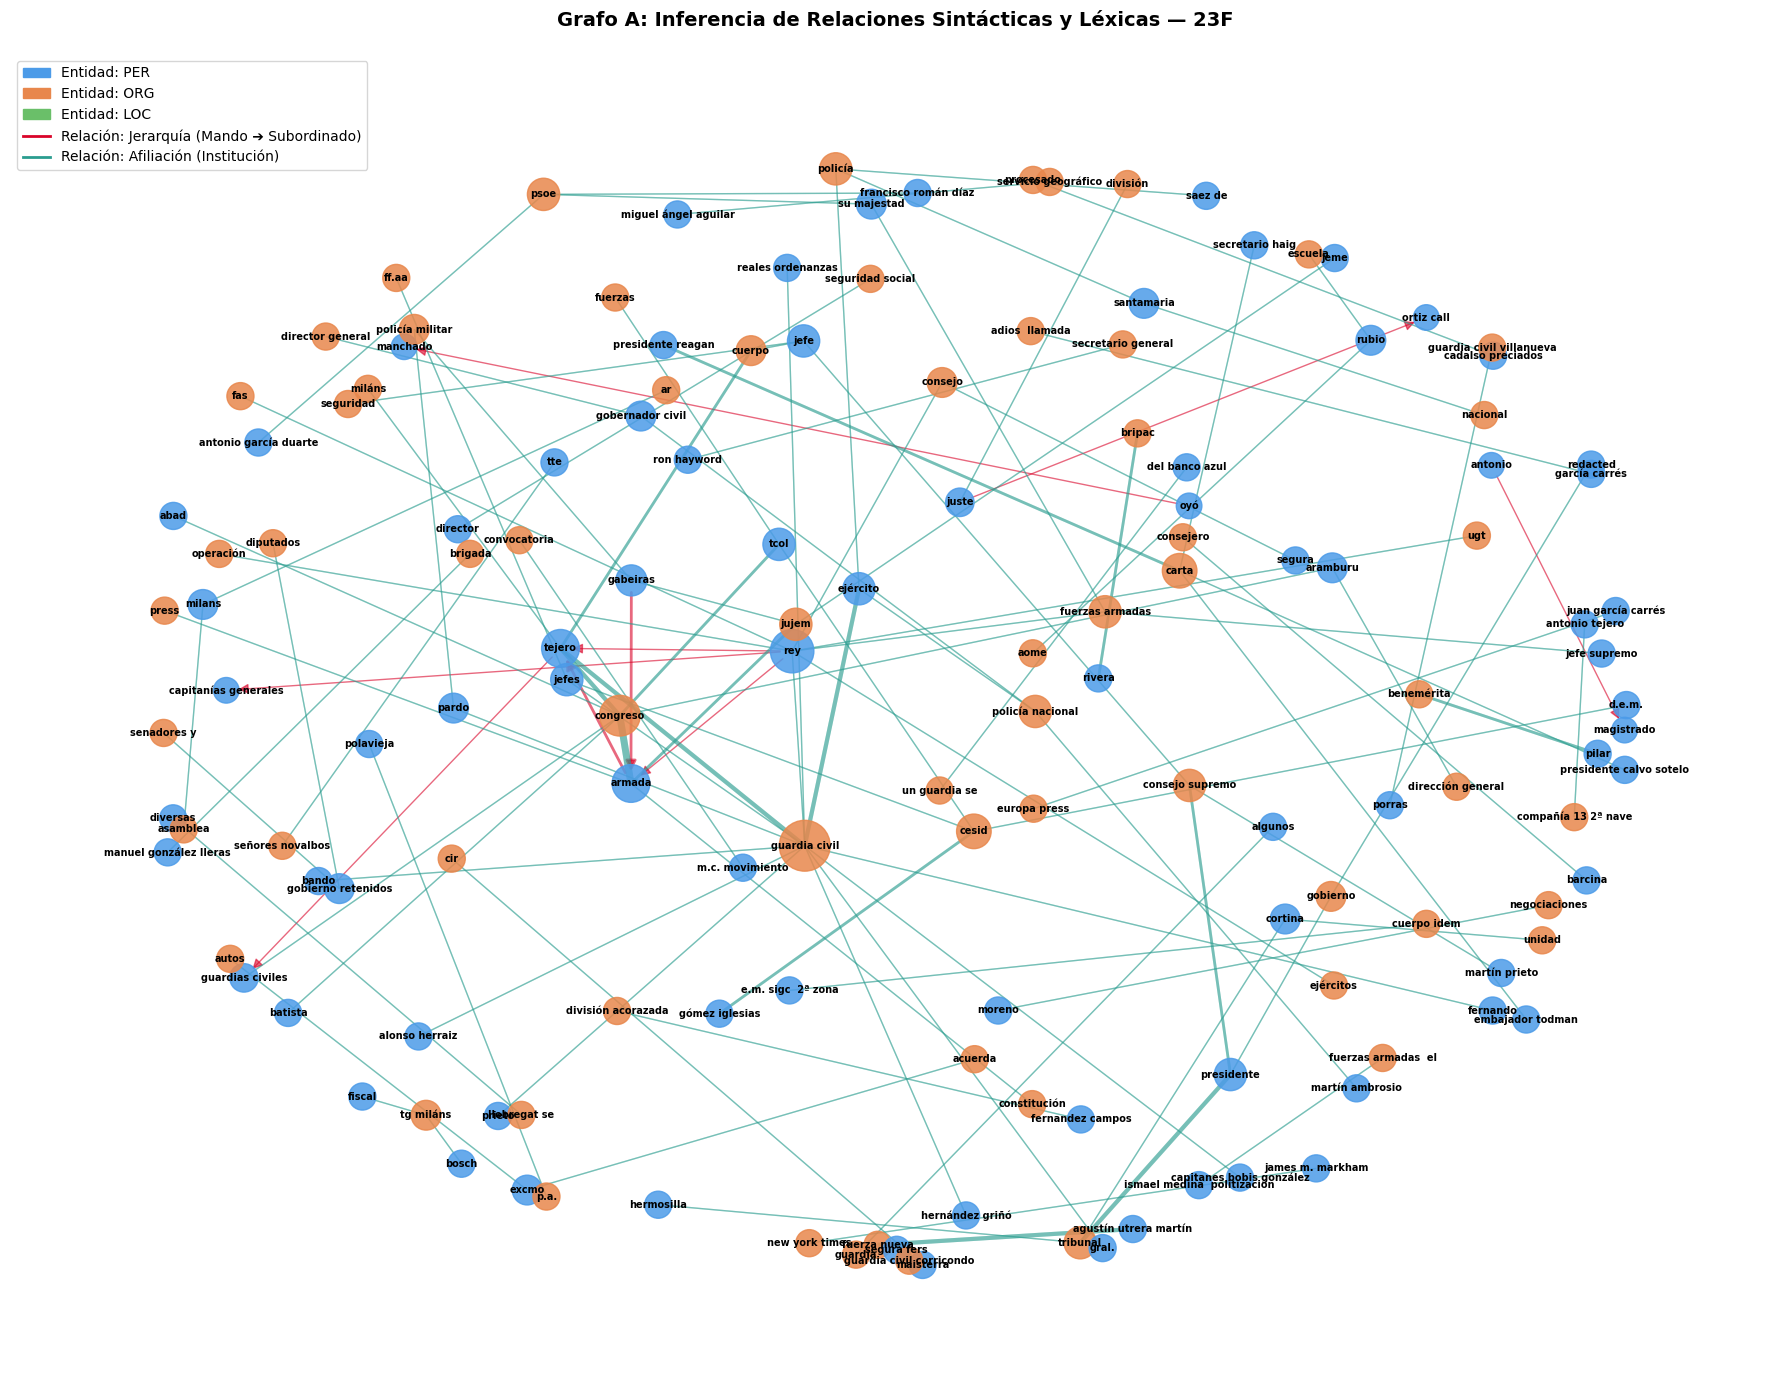

In [56]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. Configuración de filtros y subgrafo
MIN_DEGREE = 1

# Usamos G_A.degree() para asegurar consistencia si el grafo base G no está en memoria
subgraph_nodes = [n for n, d in G_A.degree() if d >= MIN_DEGREE]
G_A_sub = G_A.subgraph(subgraph_nodes)

plt.figure(figsize=(18, 14))

# 2. Cálculo de posiciones (Layout)
pos = nx.spring_layout(G_A_sub, weight="weight", seed=42, k=0.6)

# 3. Propiedades de los Nodos
node_colors = [G_A_sub.nodes[n]["color"] for n in G_A_sub.nodes()]
node_sizes  = [300 + G_A_sub.degree(n) * 40 for n in G_A_sub.nodes()]

# 4. Separación y Propiedades de los Arcos (Jerarquía vs Afiliación)
# Definimos los colores para cada tipo de relación
COLOR_JERARQUIA = "#D90429"  # Rojo vibrante
COLOR_AFILIACION = "#2A9D8F" # Verde azulado / Teal

hierarchy_edges = [(u, v) for u, v, d in G_A_sub.edges(data=True) if d.get('relation') == 'hierarchy']
affiliation_edges = [(u, v) for u, v, d in G_A_sub.edges(data=True) if d.get('relation') == 'affiliation']

hierarchy_widths = [G_A_sub[u][v]["weight"] * 1.0 for u, v in hierarchy_edges]
affiliation_widths = [G_A_sub[u][v]["weight"] * 1.0 for u, v in affiliation_edges]

# 5. Renderizado del Grafo
# Dibujar Nodos
nx.draw_networkx_nodes(G_A_sub, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)

# Dibujar Arcos de Jerarquía (Con flechas de dirección explicitadas por ser un DiGraph)
if hierarchy_edges:
    nx.draw_networkx_edges(
        G_A_sub, pos, edgelist=hierarchy_edges, width=hierarchy_widths,
        alpha=0.6, edge_color=COLOR_JERARQUIA, arrows=True, arrowsize=15, arrowstyle="-|>"
    )

# Dibujar Arcos de Afiliación (Sin flechas o sutiles, al ser relaciones bidireccionales de pertenencia)
if affiliation_edges:
    nx.draw_networkx_edges(
        G_A_sub, pos, edgelist=affiliation_edges, width=affiliation_widths,
        alpha=0.4, edge_color=COLOR_AFILIACION, arrows=False
    )

# Dibujar Etiquetas de texto
nx.draw_networkx_labels(G_A_sub, pos, font_size=7, font_color="black", font_weight="bold")

# 6. Construcción de la Leyenda Completa (Nodos + Arcos)
legend_elements = []

# Añadir tipos de entidad (Nodos - Usando Patch)
for k, v in TYPE_COLORS.items():
    if k != "UNK":
        legend_elements.append(Patch(color=v, label=f"Entidad: {k}"))

# Añadir tipos de relación (Arcos - Usando Line2D para simular líneas del grafo)
legend_elements.append(Line2D([0], [0], color=COLOR_JERARQUIA, lw=2, label="Relación: Jerarquía (Mando ➔ Subordinado)"))
legend_elements.append(Line2D([0], [0], color=COLOR_AFILIACION, lw=2, label="Relación: Afiliación (Institución)"))

plt.legend(handles=legend_elements, loc="upper left", fontsize=10, frameon=True, facecolor="white")

# 7. Títulos y exportación final
plt.title("Grafo A: Inferencia de Relaciones Sintácticas y Léxicas — 23F", fontsize=14, pad=20, weight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig("fase3_grafo_A_inferido.png", dpi=150, bbox_inches="tight")
plt.show()